# 5 Ranking CRM Gazizov

Цель ноутбука не просто улучшить ошибку в секундах, а построить практичную CRM систему приоритизации игроков.

В стандартной регрессии мы стараемся угадать точное число, но для продуктового действия чаще важнее порядок пользователей в очереди: кого трогать первым, кого вторым, а кого можно отложить.

Поэтому здесь сравниваем два подхода одновременно. Первый это обычная регрессия как контроль качества по секундам. Второй это learning to rank, где модель учится поднимать наиболее полезных игроков в верхние позиции top k.


## Что считаем в этом ноутбуке

В данных нет явных treatment и control логов кампаний, поэтому мы не делаем строгие причинные выводы про реальный uplift.

Здесь используется proxy uplift постановка. Мы оцениваем, насколько модель формирует хороший приоритетный список пользователей для CRM действий на ограниченном бюджете контактов.

Идея простая: если верхний сегмент ранжирования действительно содержит более ценных или более рискованных игроков, чем случайный выбор, значит подход полезен для практического retention процесса.


## Источники идеи

Learning to Rank for Uplift Modeling
https://arxiv.org/abs/2002.05897

CatBoost Ranking Objectives and Metrics
https://catboost.ai/docs/en/concepts/loss-functions-ranking

In [1]:
from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import ndcg_score, precision_score, recall_score

from catboost import CatBoostClassifier, CatBoostRegressor, CatBoostRanker, Pool

In [2]:
repo_root = Path.cwd()
if repo_root.name != 'ml_in_gamedev_project':
    for p in [repo_root, *repo_root.parents]:
        if p.name == 'ml_in_gamedev_project':
            repo_root = p
            break

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from preprocessing.preprocessing import (
    load_data,
    prepare_for_targets,
    regression_metrics,
    add_crm_target_7d,
)
from crm.crm_logic import build_crm_payload, crm_risk_score

## Таргеты и сплит

Берем два таргета участника 1:
- target_next_session_length_sec
- future_sessions_mean_playtime_7d

Сплит времени и фильтрация делаются через текущий preprocessing.

In [3]:
target_cols = [
    'target_next_session_length_sec',
    'future_sessions_mean_playtime_7d',
]

max_rows = 10000

df = load_data()
if 'future_sessions_mean_playtime_7d' not in df.columns:
    df = add_crm_target_7d(df)
packs = prepare_for_targets(df, target_cols=target_cols, max_rows=max_rows)

pd.DataFrame([
    {
        'target': t,
        'train_rows': len(p.x_train),
        'val_rows': len(p.x_val),
        'test_rows': len(p.x_test),
        'features': len(p.feature_cols),
        'cat_features': len(p.cat_cols),
    }
    for t, p in packs.items()
])

,target,train_rows,val_rows,test_rows,features,cat_features
0,target_next_session_length_sec,7000,1500,1500,73,14
1,future_sessions_mean_playtime_7d,7000,1500,1500,73,14


## Вспомогательные функции метрик

Считаем набор регрессионных метрик и ranking метрики top-k.

Также считаем proxy uplift gain относительно random и baseline regression ranking.

In [4]:
def wmape(y_true, y_pred):
    yt = np.asarray(y_true, dtype=float)
    yp = np.asarray(y_pred, dtype=float)
    den = np.abs(yt).sum()
    if den <= 0:
        return np.nan
    return float(np.abs(yt - yp).sum() / den)


def topk_mask(scores, k):
    n = len(scores)
    kk = max(1, int(np.ceil(n * k)))
    idx = np.argsort(-np.asarray(scores))[:kk]
    m = np.zeros(n, dtype=bool)
    m[idx] = True
    return m


def precision_at_k(y_true_bin, scores, k=0.2):
    m = topk_mask(scores, k)
    return float(np.mean(np.asarray(y_true_bin)[m]))


def recall_at_k(y_true_bin, scores, k=0.2):
    yb = np.asarray(y_true_bin)
    den = yb.sum()
    if den == 0:
        return np.nan
    m = topk_mask(scores, k)
    return float(yb[m].sum() / den)


def hitrate_at_k(y_true_bin, scores, k=0.2):
    m = topk_mask(scores, k)
    return float(np.any(np.asarray(y_true_bin)[m] > 0))


def gain_at_k(y_true, scores, k=0.2):
    yt = np.asarray(y_true, dtype=float)
    m = topk_mask(scores, k)
    top_mean = float(np.mean(yt[m]))
    rnd_mean = float(np.mean(yt))
    if abs(rnd_mean) < 1e-12:
        return np.nan
    return float((top_mean - rnd_mean) / abs(rnd_mean))

## Подготовка ranking labels

Ranking модель обучается на группах, а не на всей выборке как на плоской регрессии.

Мы формируем временные группы и внутри каждой группы помечаем top q пользователей по факту как более полезных для приоритизации.

В ноутбуке сравниваются два уровня строгости q. Это нужно, чтобы понять, насколько стабильны выводы при более узком и более широком понятии полезного верхнего сегмента.


In [5]:
def make_group_ids(frame, time_col='start', freq='W'):
    t = pd.to_datetime(frame[time_col], errors='coerce')
    g = t.dt.to_period(freq).astype(str)
    return np.asarray(g.fillna('unknown_group').astype(str), dtype=str)


def make_binary_utility(y, group_ids, q=0.2):
    y = np.asarray(y, dtype=float)
    out = np.zeros(len(y), dtype=np.float32)
    s = pd.Series(y)
    gg = pd.Series(group_ids)

    for g in gg.unique():
        idx = np.where(gg.values == g)[0]
        if len(idx) < 2:
            continue
        yy = s.iloc[idx].values
        thr = np.quantile(yy, 1 - q)
        out[idx] = (yy >= thr).astype(np.float32)

    return out


def ensure_valid_groups(group_ids, min_size=2):
    s = pd.Series(group_ids)
    cnt = s.value_counts()
    ok = cnt[cnt >= min_size].index
    return s.isin(ok).values

def unique_player_positions(raw_frame, group_ids, player_col='installation_id'):
    tmp = raw_frame.reset_index(drop=True).copy()
    tmp['_pos'] = np.arange(len(tmp))
    tmp['_group_id'] = np.asarray(group_ids, dtype=str)
    tmp = tmp.dropna(subset=[player_col]).copy()
    tmp = tmp.sort_values(['_group_id', 'start', '_pos'])
    tmp = tmp.drop_duplicates(['_group_id', player_col], keep='last')
    return np.sort(tmp['_pos'].to_numpy(dtype=int))

## Конфигурации моделей

Регрессия для контроля:
- reg_mae
- reg_quantile_04

Ranking:
- rank_yetirank_q20
- rank_pairlogit_q20
- rank_yetirank_q30
- rank_pairlogit_q30

In [6]:
reg_modes = [
    {'mode': 'reg_mae', 'loss': 'MAE'},
    {'mode': 'reg_quantile_04', 'loss': 'Quantile:alpha=0.40'},
]

rank_modes = [
    {'mode': 'rank_yetirank_q20', 'loss': 'YetiRank', 'q': 0.2},
    {'mode': 'rank_pairlogit_q20', 'loss': 'PairLogit:max_pairs=5000', 'q': 0.2},
    {'mode': 'rank_yetirank_q30', 'loss': 'YetiRank', 'q': 0.3},
    {'mode': 'rank_pairlogit_q30', 'loss': 'PairLogit:max_pairs=5000', 'q': 0.3},
]

base_params = {
    'iterations': 150,
    'depth': 6,
    'learning_rate': 0.05,
    'l2_leaf_reg': 5.0,
    'random_seed': 42,
    'verbose': False,
}

## Запуск экспериментов

На каждом таргете мы прогоняем и регрессионные, и ranking режимы в едином контуре данных.

Для ranking моделей итоговый score это ранговый приоритет. Поэтому оценка идет не только через MAE и R2, но и через метрики качества верхнего сегмента: NDCG, precision at k, recall at k и gain относительно случайного выбора.

Отдельно считаем proxy регрессионную витрину для ranking score, чтобы видеть, какой ценой по точности секунд достигается выигрыш в приоритизации.


In [7]:
rows = []
trained_rankers = {}
rank_scores_test = {}
rank_test_frames = {}

for t_col, p in packs.items():
    tr_x = p.x_train.copy()
    va_x = p.x_val.copy()
    te_x = p.x_test.copy()

    y_tr = p.y_train.copy()
    y_va = p.y_val.copy()
    y_te = p.y_test.copy()

    if 'start' in df.columns:
        x0 = df.copy()
        x0['start'] = pd.to_datetime(x0['start'], errors='coerce')
        x0 = x0[x0['start'].notna()]
        x0 = x0[x0[t_col].notna()]
        x0 = x0.sort_values('start').reset_index(drop=True)
        if len(x0) > max_rows:
            x0 = x0.tail(max_rows).reset_index(drop=True)
        n = len(x0)
        i1 = int(n * 0.70)
        i2 = int(n * 0.85)
        tr_time = x0.iloc[:i1]['start'].reset_index(drop=True)
        va_time = x0.iloc[i1:i2]['start'].reset_index(drop=True)
        te_time = x0.iloc[i2:]['start'].reset_index(drop=True)
    else:
        tr_time = pd.Series(np.arange(len(tr_x)))
        va_time = pd.Series(np.arange(len(va_x)))
        te_time = pd.Series(np.arange(len(te_x)))

    tr_raw = x0.iloc[:i1].reset_index(drop=True)
    va_raw = x0.iloc[i1:i2].reset_index(drop=True)
    te_raw = x0.iloc[i2:].reset_index(drop=True)

    tr_g = make_group_ids(pd.DataFrame({'start': tr_time}), time_col='start', freq='W')
    va_g = make_group_ids(pd.DataFrame({'start': va_time}), time_col='start', freq='W')
    te_g = make_group_ids(pd.DataFrame({'start': te_time}), time_col='start', freq='W')

    tr_pos = unique_player_positions(tr_raw, tr_g)
    va_pos = unique_player_positions(va_raw, va_g)
    te_pos = unique_player_positions(te_raw, te_g)

    tr_keep = ensure_valid_groups(tr_g[tr_pos])
    va_keep = ensure_valid_groups(va_g[va_pos])
    te_keep = ensure_valid_groups(te_g[te_pos])

    tr_pos = tr_pos[tr_keep]
    va_pos = va_pos[va_keep]
    te_pos = te_pos[te_keep]

    tr_xg = tr_x.iloc[tr_pos].reset_index(drop=True)
    va_xg = va_x.iloc[va_pos].reset_index(drop=True)
    te_xg = te_x.iloc[te_pos].reset_index(drop=True)
    te_rawg = te_raw.iloc[te_pos].reset_index(drop=True)
    te_rawg['_pack_row'] = te_pos
    rank_test_frames[t_col] = te_rawg

    y_trg = y_tr[tr_pos]
    y_vag = y_va[va_pos]
    y_teg = y_te[te_pos]

    tr_gg = np.asarray(tr_g[tr_pos], dtype=str)
    va_gg = np.asarray(va_g[va_pos], dtype=str)
    te_gg = np.asarray(te_g[te_pos], dtype=str)

    cat_idx = [tr_x.columns.get_loc(c) for c in p.cat_cols if c in tr_x.columns]

    for m in reg_modes:
        st = time.time()
        model = CatBoostRegressor(
            loss_function=m['loss'],
            eval_metric='MAE',
            **base_params,
        )

        model.fit(
            tr_x,
            y_tr,
            cat_features=cat_idx,
            eval_set=(va_x, y_va),
            use_best_model=True,
        )

        fit_sec = time.time() - st

        pred_va = np.maximum(model.predict(va_x), 0.0)
        pred_te = np.maximum(model.predict(te_x), 0.0)

        m_va = regression_metrics(y_va, pred_va)
        m_te = regression_metrics(y_te, pred_te)

        u_va = (y_vag >= np.quantile(y_vag, 0.8)).astype(int)
        u_te = (y_teg >= np.quantile(y_teg, 0.8)).astype(int)

        ndcg_va = float(ndcg_score([u_va], [pred_va[va_pos]], k=max(10, int(0.2 * len(u_va)))))
        ndcg_te = float(ndcg_score([u_te], [pred_te[te_pos]], k=max(10, int(0.2 * len(u_te)))))

        row = {
            'target': t_col,
            'mode': m['mode'],
            'kind': 'regression',
            'q': np.nan,
            'fit_sec': fit_sec,
            'val_ndcg_k20': ndcg_va,
            'test_ndcg_k20': ndcg_te,
            'val_precision_k20': precision_at_k(u_va, pred_va[va_pos], 0.2),
            'test_precision_k20': precision_at_k(u_te, pred_te[te_pos], 0.2),
            'val_recall_k20': recall_at_k(u_va, pred_va[va_pos], 0.2),
            'test_recall_k20': recall_at_k(u_te, pred_te[te_pos], 0.2),
            'val_hitrate_k20': hitrate_at_k(u_va, pred_va[va_pos], 0.2),
            'test_hitrate_k20': hitrate_at_k(u_te, pred_te[te_pos], 0.2),
            'val_gain_k20': gain_at_k(y_vag, pred_va[va_pos], 0.2),
            'test_gain_k20': gain_at_k(y_teg, pred_te[te_pos], 0.2),
            'val_gain_k30': gain_at_k(y_vag, pred_va[va_pos], 0.3),
            'test_gain_k30': gain_at_k(y_teg, pred_te[te_pos], 0.3),
            'val_wmape': wmape(y_va, pred_va),
            'test_wmape': wmape(y_te, pred_te),
        }

        row.update({f'val_{k}': v for k, v in m_va.items()})
        row.update({f'test_{k}': v for k, v in m_te.items()})
        rows.append(row)

    for m in rank_modes:
        q = m['q']
        y_tr_u = make_binary_utility(y_trg, tr_gg, q=q)
        y_va_u = make_binary_utility(y_vag, va_gg, q=q)
        y_te_u = make_binary_utility(y_teg, te_gg, q=q)

        st = time.time()
        ranker = CatBoostRanker(
            loss_function=m['loss'],
            eval_metric='NDCG:top=20',
            **base_params,
        )

        tr_pool = Pool(tr_xg, y_tr_u, group_id=tr_gg, cat_features=cat_idx)
        va_pool = Pool(va_xg, y_va_u, group_id=va_gg, cat_features=cat_idx)
        te_pool = Pool(te_xg, y_te_u, group_id=te_gg, cat_features=cat_idx)

        ranker.fit(
            tr_pool,
            eval_set=va_pool,
            use_best_model=True,
            verbose=False,
        )

        fit_sec = time.time() - st

        s_va = ranker.predict(va_pool)
        s_te = ranker.predict(te_pool)
        trained_rankers[(t_col, m['mode'])] = ranker
        rank_scores_test[(t_col, m['mode'])] = s_te

        pred_va = np.interp(s_va, (s_va.min(), s_va.max()), (np.percentile(y_tr, 20), np.percentile(y_tr, 90)))
        pred_te = np.interp(s_te, (s_te.min(), s_te.max()), (np.percentile(y_tr, 20), np.percentile(y_tr, 90)))

        m_va = regression_metrics(y_vag, pred_va)
        m_te = regression_metrics(y_teg, pred_te)

        row = {
            'target': t_col,
            'mode': m['mode'],
            'kind': 'ranking',
            'q': q,
            'fit_sec': fit_sec,
            'val_ndcg_k20': float(ndcg_score([y_va_u], [s_va], k=max(10, int(0.2 * len(y_va_u))))),
            'test_ndcg_k20': float(ndcg_score([y_te_u], [s_te], k=max(10, int(0.2 * len(y_te_u))))),
            'val_precision_k20': precision_at_k(y_va_u, s_va, 0.2),
            'test_precision_k20': precision_at_k(y_te_u, s_te, 0.2),
            'val_recall_k20': recall_at_k(y_va_u, s_va, 0.2),
            'test_recall_k20': recall_at_k(y_te_u, s_te, 0.2),
            'val_hitrate_k20': hitrate_at_k(y_va_u, s_va, 0.2),
            'test_hitrate_k20': hitrate_at_k(y_te_u, s_te, 0.2),
            'val_gain_k20': gain_at_k(y_vag, s_va, 0.2),
            'test_gain_k20': gain_at_k(y_teg, s_te, 0.2),
            'val_gain_k30': gain_at_k(y_vag, s_va, 0.3),
            'test_gain_k30': gain_at_k(y_teg, s_te, 0.3),
            'val_wmape': wmape(y_vag, pred_va),
            'test_wmape': wmape(y_teg, pred_te),
        }

        row.update({f'val_{k}': v for k, v in m_va.items()})
        row.update({f'test_{k}': v for k, v in m_te.items()})
        rows.append(row)

res = pd.DataFrame(rows)
res.head()

,target,mode,kind,q,fit_sec,val_ndcg_k20,test_ndcg_k20,val_precision_k20,test_precision_k20,val_recall_k20,...,test_mae,test_medae,test_p70_abs_error,test_p90_abs_error,test_r2,test_product_mae,test_engagement_risk_mae,test_small_mae,test_normal_mae,test_long_mae
0,target_next_session_length_sec,reg_mae,regression,NaN,0.678962,0.410144,0.386250,0.363636,0.343750,0.363636,...,359.293861,180.157024,333.157263,831.735423,0.057143,209.194135,213.449535,166.319479,312.814364,1753.434428
1,target_next_session_length_sec,reg_quantile_04,regression,NaN,0.533437,0.409596,0.357821,0.372727,0.322917,0.372727,...,360.103688,153.270618,315.052898,890.466549,-0.039973,190.441258,191.786674,112.243865,379.519120,1883.253679
2,target_next_session_length_sec,rank_yetirank_q20,ranking,0.2,1.857838,0.391080,0.387156,0.354545,0.354167,0.354545,...,581.467249,437.810814,631.387572,1029.005155,0.107728,438.428002,457.054704,508.811949,309.105589,1438.483519
3,target_next_session_length_sec,rank_pairlogit_q20,ranking,0.2,0.589087,0.359811,0.374463,0.363636,0.364583,0.363636,...,681.270529,580.556197,772.064917,1174.227534,0.009318,564.629688,610.552011,703.481744,381.085203,1282.033153
4,target_next_session_length_sec,rank_yetirank_q30,ranking,0.3,2.213722,0.495518,0.491620,0.454545,0.510417,0.303030,...,681.744633,564.925485,828.918815,1238.670572,-0.014660,559.485933,608.140033,689.594943,404.254398,1279.711902


## Проверка ranking постановки

Проверяем, что группы корректные и в данных нет пустых group id.

In [8]:
check = []
for t_col, p in packs.items():
    x0 = df.copy()
    x0['start'] = pd.to_datetime(x0['start'], errors='coerce')
    x0 = x0[x0['start'].notna()]
    x0 = x0[x0[t_col].notna()]
    x0 = x0.sort_values('start').reset_index(drop=True)
    if len(x0) > max_rows:
        x0 = x0.tail(max_rows).reset_index(drop=True)

    g = make_group_ids(x0[['start']], time_col='start', freq='W')
    cnt = pd.Series(g).value_counts()

    check.append({
        'target': t_col,
        'rows': len(x0),
        'groups': int(cnt.shape[0]),
        'min_group_size': int(cnt.min()),
        'median_group_size': float(cnt.median()),
        'max_group_size': int(cnt.max()),
        'na_group_ids': int(pd.isna(g).sum()),
    })

pd.DataFrame(check)

,target,rows,groups,min_group_size,median_group_size,max_group_size,na_group_ids
0,target_next_session_length_sec,10000,1,10000,10000.0,10000,0
1,future_sessions_mean_playtime_7d,10000,1,10000,10000.0,10000,0


## Основные таблицы сравнения

В этих таблицах рядом с MAE всегда выводится R2, как ты просил.

Дальше в одной витрине лежат и стандартные регрессионные ошибки, и ranking метрики верхнего сегмента. Такой формат удобен для принятия решения, потому что сразу видно trade off между точностью секунд и продуктовой ценностью ранжирования.


In [9]:
main_cols = [
    'target', 'mode', 'kind', 'q',
    'val_mae', 'val_r2', 'test_mae', 'test_r2',
    'val_product_mae', 'test_product_mae',
    'val_engagement_risk_mae', 'test_engagement_risk_mae',
    'val_medae', 'test_medae',
    'val_p70_abs_error', 'test_p70_abs_error',
    'val_p90_abs_error', 'test_p90_abs_error',
    'val_small_mae', 'test_small_mae',
    'val_normal_mae', 'test_normal_mae',
    'val_long_mae', 'test_long_mae',
    'val_wmape', 'test_wmape',
    'val_ndcg_k20', 'test_ndcg_k20',
    'val_precision_k20', 'test_precision_k20',
    'val_recall_k20', 'test_recall_k20',
    'val_hitrate_k20', 'test_hitrate_k20',
    'val_gain_k20', 'test_gain_k20',
    'val_gain_k30', 'test_gain_k30',
    'fit_sec'
]

res[main_cols].sort_values(['target', 'test_mae']).reset_index(drop=True)

,target,mode,kind,q,val_mae,val_r2,test_mae,test_r2,val_product_mae,test_product_mae,...,test_precision_k20,val_recall_k20,test_recall_k20,val_hitrate_k20,test_hitrate_k20,val_gain_k20,test_gain_k20,val_gain_k30,test_gain_k30,fit_sec
0,future_sessions_mean_playtime_7d,reg_mae,regression,NaN,283.103956,0.186796,275.981575,0.240964,198.700258,209.515305,...,0.507692,0.500000,0.507692,1.0,1.0,0.745236,0.727097,0.610344,0.596633,0.554028
1,future_sessions_mean_playtime_7d,reg_quantile_04,regression,NaN,283.098076,0.137669,284.946259,0.162868,183.065167,202.689990,...,0.492308,0.532787,0.492308,1.0,1.0,0.784810,0.754575,0.642870,0.619120,0.488803
2,future_sessions_mean_playtime_7d,rank_yetirank_q20,ranking,0.2,346.944989,0.212960,353.446500,0.194496,274.258964,283.415092,...,0.461538,0.475410,0.461538,1.0,1.0,0.724337,0.702710,0.581168,0.580645,2.631832
3,future_sessions_mean_playtime_7d,rank_pairlogit_q20,ranking,0.2,369.715482,0.205170,362.593973,0.199214,312.076261,296.002931,...,0.507692,0.475410,0.507692,1.0,1.0,0.737336,0.783811,0.600725,0.599708,0.656944
4,future_sessions_mean_playtime_7d,rank_pairlogit_q30,ranking,0.3,377.843730,0.190731,381.190113,0.164501,319.300805,322.414943,...,0.623077,0.382514,0.417526,1.0,1.0,0.595334,0.735025,0.559464,0.538065,0.645366
5,future_sessions_mean_playtime_7d,rank_yetirank_q30,ranking,0.3,373.988045,0.188873,381.885255,0.152905,308.051692,319.675861,...,0.592308,0.377049,0.396907,1.0,1.0,0.615251,0.699366,0.509589,0.555234,2.314547
6,target_next_session_length_sec,reg_mae,regression,NaN,467.191475,0.022431,359.293861,0.057143,233.609461,209.194135,...,0.343750,0.363636,0.343750,1.0,1.0,0.662097,0.853822,0.604677,0.582369,0.678962
7,target_next_session_length_sec,reg_quantile_04,regression,NaN,470.249654,-0.067749,360.103688,-0.039973,206.783445,190.441258,...,0.322917,0.372727,0.322917,1.0,1.0,0.717848,0.710919,0.655500,0.531575,0.533437
8,target_next_session_length_sec,rank_yetirank_q20,ranking,0.2,637.556247,0.079394,581.467249,0.107728,457.391152,438.428002,...,0.354167,0.354545,0.354167,1.0,1.0,0.725079,0.797293,0.514313,0.664942,1.857838
9,target_next_session_length_sec,rank_pairlogit_q30,ranking,0.3,745.593728,-0.002367,666.286733,0.002986,591.501882,536.090696,...,0.447917,0.327273,0.300699,1.0,1.0,0.638533,0.743159,0.503735,0.507606,0.681362


In [10]:
best_mae = res.sort_values('test_mae').groupby('target', as_index=False).first()
best_rank = res.sort_values('test_ndcg_k20', ascending=False).groupby('target', as_index=False).first()
best_gain = res.sort_values('test_gain_k20', ascending=False).groupby('target', as_index=False).first()

best_mae[['target', 'mode', 'test_mae', 'test_r2', 'test_product_mae', 'test_engagement_risk_mae', 'test_ndcg_k20', 'test_gain_k20']]

,target,mode,test_mae,test_r2,test_product_mae,test_engagement_risk_mae,test_ndcg_k20,test_gain_k20
0,future_sessions_mean_playtime_7d,reg_mae,275.981575,0.240964,209.515305,216.863310,0.559924,0.727097
1,target_next_session_length_sec,reg_mae,359.293861,0.057143,209.194135,213.449535,0.386250,0.853822


In [11]:
best_rank[['target', 'mode', 'test_ndcg_k20', 'test_precision_k20', 'test_recall_k20', 'test_gain_k20', 'test_mae', 'test_r2']]

,target,mode,test_ndcg_k20,test_precision_k20,test_recall_k20,test_gain_k20,test_mae,test_r2
0,future_sessions_mean_playtime_7d,rank_pairlogit_q30,0.663234,0.623077,0.417526,0.735025,381.190113,0.164501
1,target_next_session_length_sec,rank_pairlogit_q30,0.495783,0.447917,0.300699,0.743159,666.286733,0.002986


In [12]:
best_gain[['target', 'mode', 'test_gain_k20', 'test_gain_k30', 'test_ndcg_k20', 'test_mae', 'test_r2']]

,target,mode,test_gain_k20,test_gain_k30,test_ndcg_k20,test_mae,test_r2
0,future_sessions_mean_playtime_7d,rank_pairlogit_q20,0.783811,0.599708,0.537676,362.593973,0.199214
1,target_next_session_length_sec,rank_pairlogit_q20,0.909630,0.563614,0.374463,681.270529,0.009318


## Графики сравнения

Сначала смотрим базовые графики по MAE и ProductMAE, чтобы не потерять связь с предыдущими ноутбуками.

Потом смотрим ranking графики по NDCG и precision at k. Они показывают, насколько хорошо режимы формируют верхнюю часть списка для CRM действий.

Scatter график нужен как компактная карта компромисса: по оси X стоимость в ошибке секунд, по оси Y выигрыш в ранжировании.


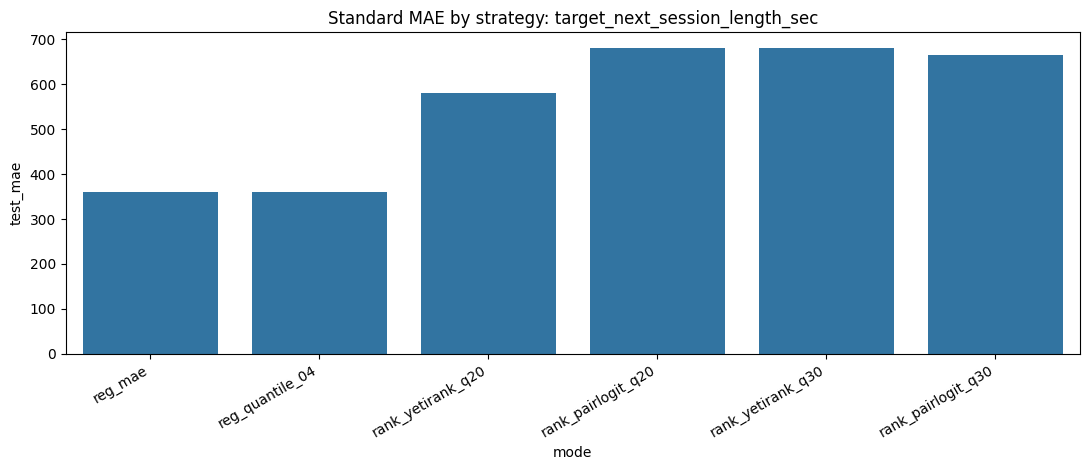

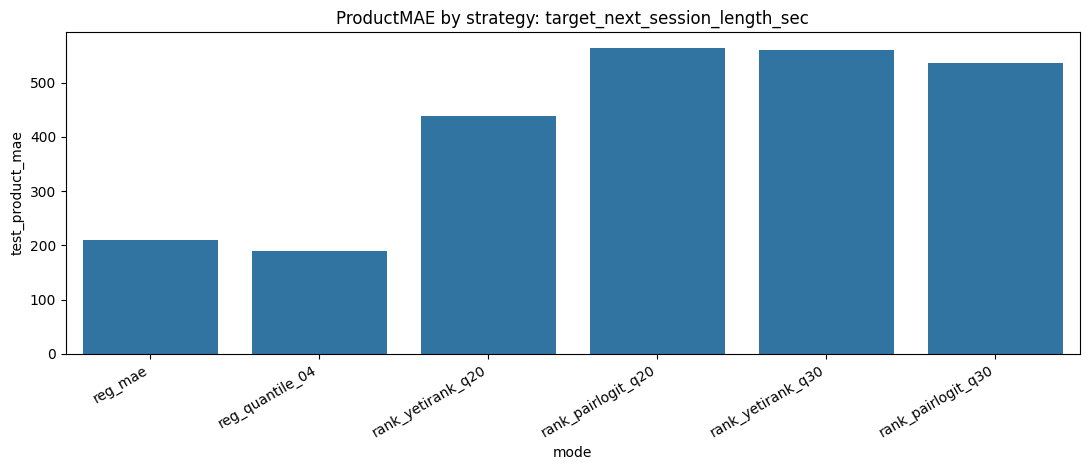

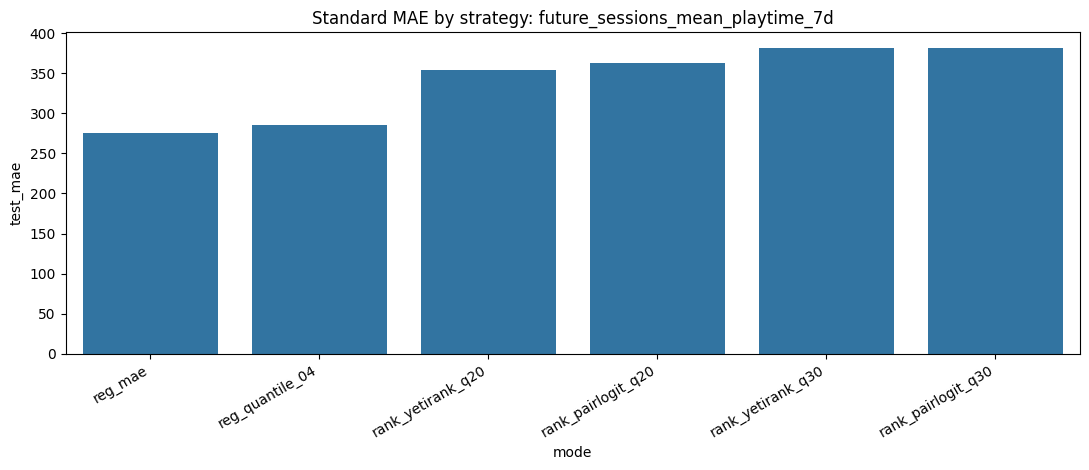

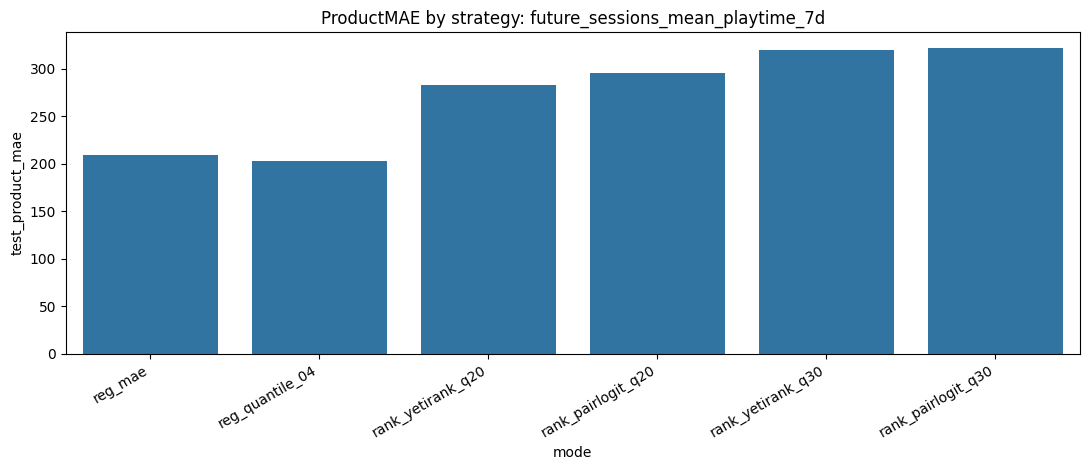

In [13]:
for t_col in target_cols:
    x = res[res['target'] == t_col].copy()

    plt.figure(figsize=(11, 4.8))
    sns.barplot(data=x, x='mode', y='test_mae', color='#1f77b4')
    plt.title(f'Standard MAE by strategy: {t_col}')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(11, 4.8))
    sns.barplot(data=x, x='mode', y='test_product_mae', color='#1f77b4')
    plt.title(f'ProductMAE by strategy: {t_col}')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

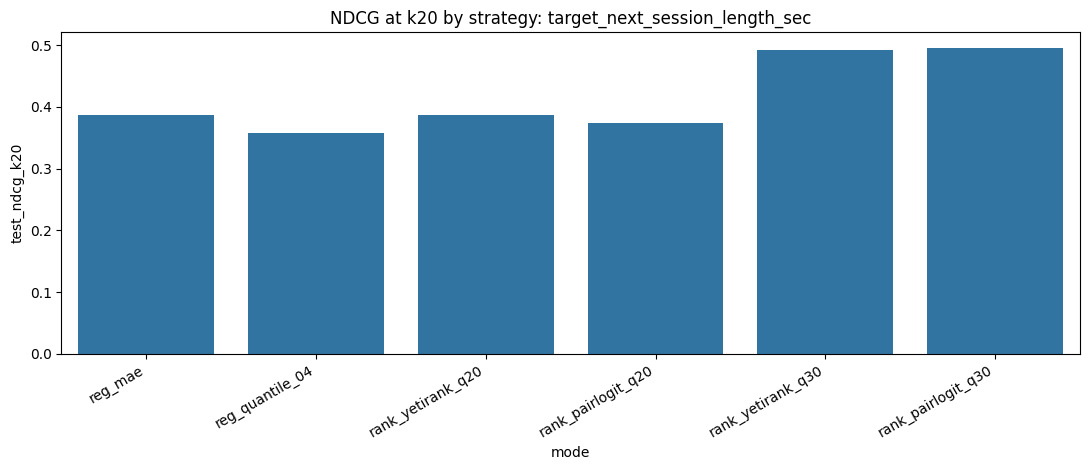

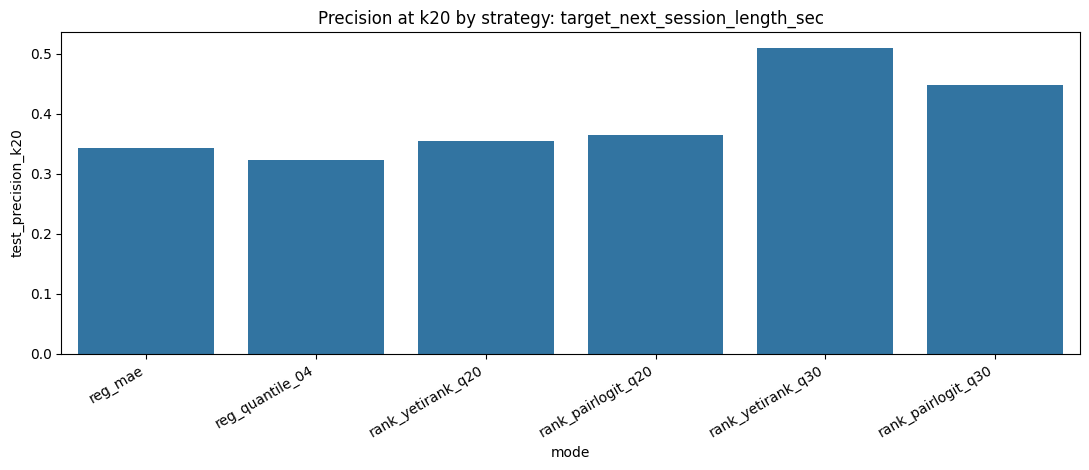

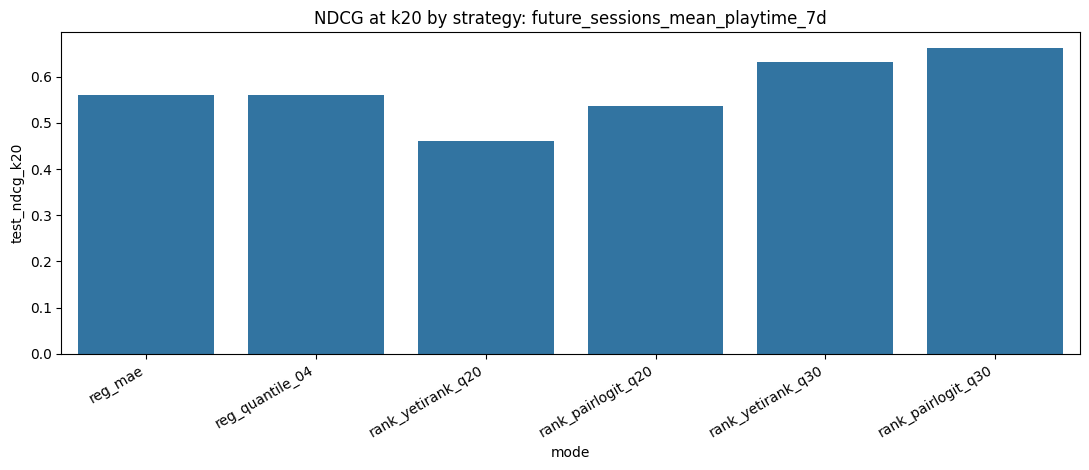

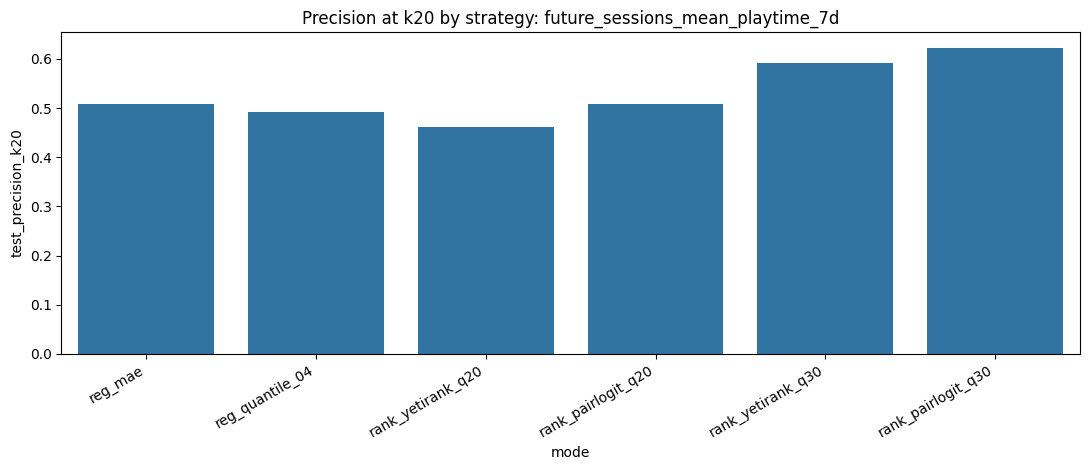

In [14]:
for t_col in target_cols:
    x = res[res['target'] == t_col].copy()

    plt.figure(figsize=(11, 4.8))
    sns.barplot(data=x, x='mode', y='test_ndcg_k20', color='#1f77b4')
    plt.title(f'NDCG at k20 by strategy: {t_col}')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(11, 4.8))
    sns.barplot(data=x, x='mode', y='test_precision_k20', color='#1f77b4')
    plt.title(f'Precision at k20 by strategy: {t_col}')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

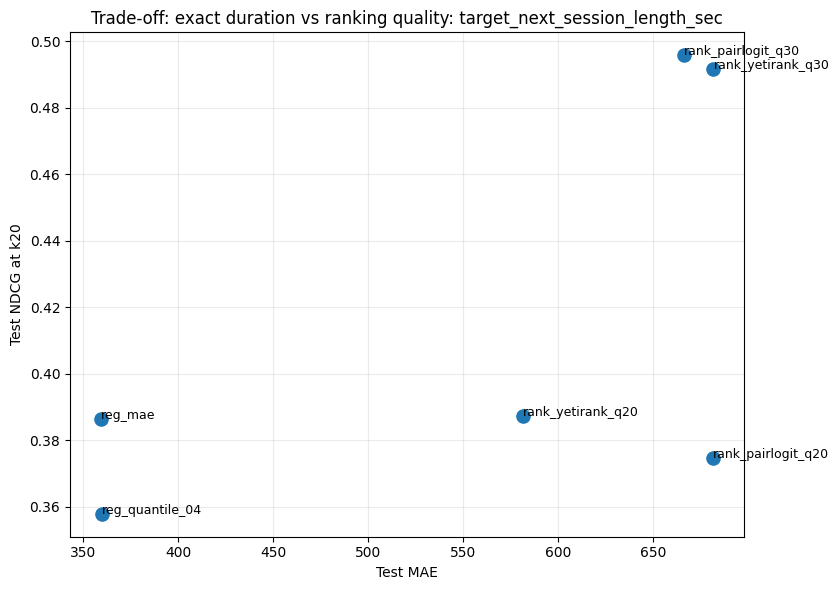

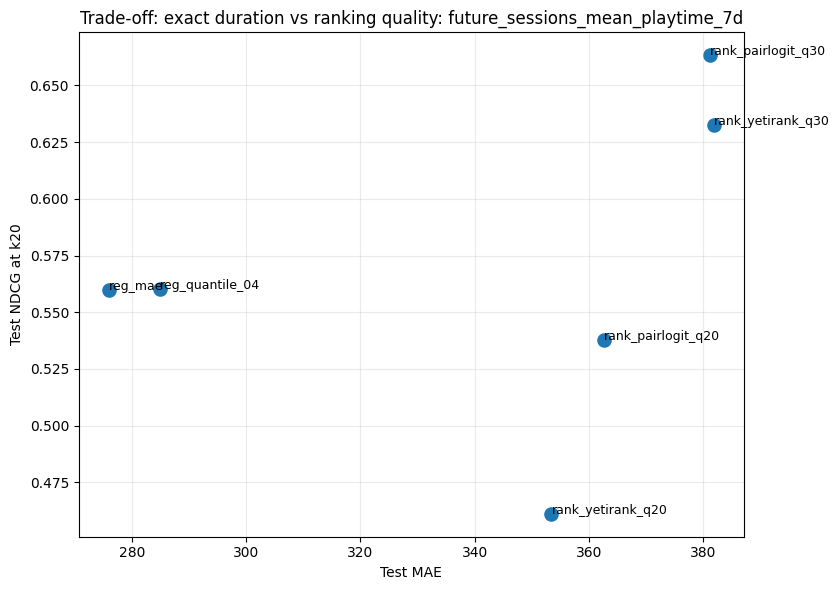

In [15]:
for t_col in target_cols:
    x = res[res['target'] == t_col].copy()

    plt.figure(figsize=(8.5, 6.0))
    plt.scatter(x['test_mae'], x['test_ndcg_k20'], s=90)
    for _, r in x.iterrows():
        plt.text(r['test_mae'], r['test_ndcg_k20'], r['mode'], fontsize=9)
    plt.xlabel('Test MAE')
    plt.ylabel('Test NDCG at k20')
    plt.title(f'Trade-off: exact duration vs ranking quality: {t_col}')
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

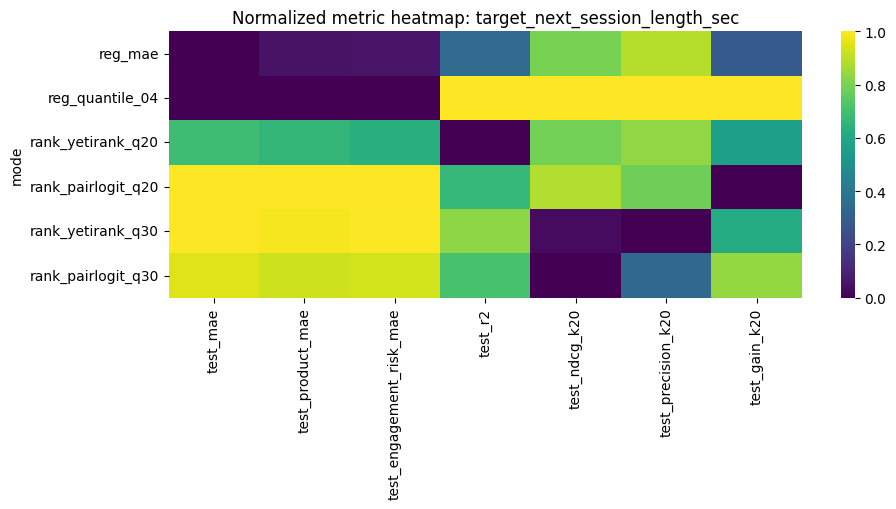

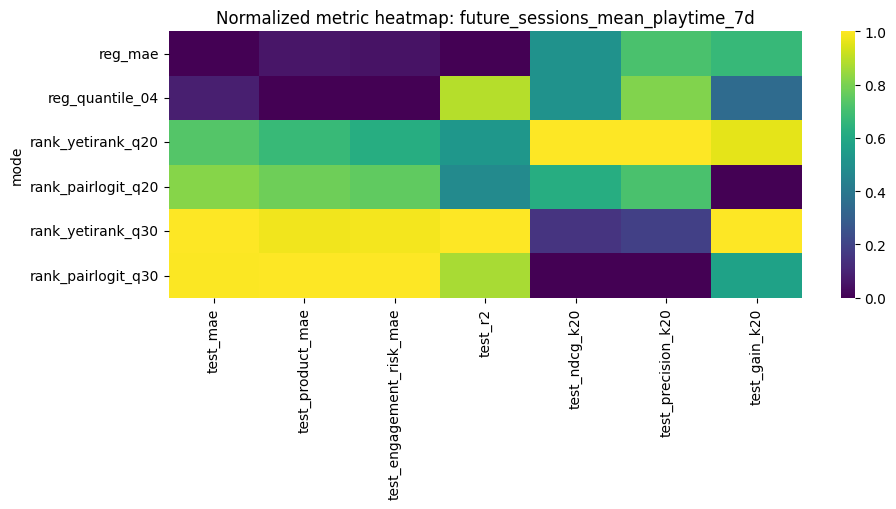

In [16]:
for t_col in target_cols:
    x = res[res['target'] == t_col].copy()

    hm_cols = [
        'test_mae',
        'test_product_mae',
        'test_engagement_risk_mae',
        'test_r2',
        'test_ndcg_k20',
        'test_precision_k20',
        'test_gain_k20',
    ]

    z = x[['mode', *hm_cols]].set_index('mode').copy()

    z2 = z.copy()
    err_cols = ['test_mae', 'test_product_mae', 'test_engagement_risk_mae']
    for c in err_cols:
        a = z2[c]
        z2[c] = (a - a.min()) / (a.max() - a.min() + 1e-12)

    good_cols = ['test_r2', 'test_ndcg_k20', 'test_precision_k20', 'test_gain_k20']
    for c in good_cols:
        a = z2[c]
        xnorm = (a - a.min()) / (a.max() - a.min() + 1e-12)
        z2[c] = 1 - xnorm

    plt.figure(figsize=(9.8, 5.2))
    sns.heatmap(z2, cmap='viridis', cbar=True)
    plt.title(f'Normalized metric heatmap: {t_col}')
    plt.tight_layout()
    plt.show()

## Компромиссный рейтинг режимов

Обычно один режим не выигрывает сразу по всем критериям.

Поэтому делаем нормировку метрик и считаем общий rank sum. Это не абсолютная истина, а удобный способ получить прагматичный компромиссный выбор без ручного перебора десятков строк таблицы.


In [17]:
def choose_compromise(frame):
    x = frame.copy()

    min_cols = ['test_mae', 'test_product_mae', 'test_engagement_risk_mae']
    max_cols = ['test_r2', 'test_ndcg_k20', 'test_precision_k20', 'test_gain_k20']

    for c in min_cols:
        a = x[c]
        x[f'n_{c}'] = (a - a.min()) / (a.max() - a.min() + 1e-12)

    for c in max_cols:
        a = x[c]
        n = (a - a.min()) / (a.max() - a.min() + 1e-12)
        x[f'n_{c}'] = 1 - n

    n_cols = [c for c in x.columns if c.startswith('n_')]
    x['rank_sum'] = x[n_cols].sum(axis=1)
    return x.sort_values('rank_sum').reset_index(drop=True)

comp = []
for t_col in target_cols:
    tmp = choose_compromise(res[res['target'] == t_col])
    comp.append(tmp.iloc[0])

comp = pd.DataFrame(comp)
comp[['target', 'mode', 'test_mae', 'test_r2', 'test_ndcg_k20', 'test_gain_k20', 'rank_sum']]

,target,mode,test_mae,test_r2,test_ndcg_k20,test_gain_k20,rank_sum
0,target_next_session_length_sec,reg_mae,359.293861,0.057143,0.386250,0.853822,2.408009
0,future_sessions_mean_playtime_7d,reg_mae,275.981575,0.240964,0.559924,0.727097,2.004702


## Финальный вывод

Финальный выбор делаем отдельно под каждую задачу.

Если цель это точность длительности в секундах, берем лидера по MAE и проверяем, что R2 и хвостовые ошибки не развалились.

Если цель это CRM приоритизация при ограниченном ресурсе, берем лидера по ranking метрикам и gain в top k.

Если нужна одна универсальная конфигурация для старта, используем компромиссный режим по rank sum и фиксируем его как базу для следующего цикла улучшений.


## Интеграция ranking и CRM логики

До этого блока notebook сравнивает способы ранжирования. Теперь собираем прикладной CRM результат: ranking отвечает за порядок игроков, а общий CRM модуль назначает сегменты, флаги риска и рекомендуемый сценарий.

Строим две отдельные очереди. Value queue нужна для игроков с высокой ожидаемой недельной вовлеченностью. Retention queue нужна для игроков с высоким риском ухода и низкой ожидаемой вовлеченностью. В каждой очереди оставляем top 20 процентов уникальных игроков.

In [18]:
from crm.crm_logic import build_crm_payload, crm_risk_score


def add_churn_target_7d(frame, horizon_days=7):
    x = frame.copy()
    x["start"] = pd.to_datetime(x["start"], errors="coerce")
    x = x[x["start"].notna() & x["installation_id"].notna()].copy()
    x = x.sort_values(["installation_id", "start"]).reset_index(drop=True)

    delta_ns = np.int64(horizon_days * 24 * 3600 * 1_000_000_000)
    future_count = np.zeros(len(x), dtype=np.int32)

    for _, pos in x.groupby("installation_id", sort=False).indices.items():
        pos = np.asarray(pos, dtype=np.int64)
        t = x.iloc[pos]["start"].values.astype("datetime64[ns]").astype(np.int64)
        nxt = np.arange(len(pos), dtype=np.int64) + 1
        right = np.searchsorted(t, t + delta_ns, side="right")
        future_count[pos] = np.maximum(right - nxt, 0)

    last_observed = x["start"].max().value - delta_ns
    observed = x["start"].values.astype("datetime64[ns]").astype(np.int64) <= last_observed
    x["churn_7d"] = np.where(observed, (future_count == 0).astype(int), np.nan)
    return x


def prepare_churn_train(frame, feature_cols, max_rows=10000):
    x = frame[frame["churn_7d"].notna()].sort_values("start").tail(max_rows).reset_index(drop=True)
    i1 = int(len(x) * 0.70)
    i2 = int(len(x) * 0.85)
    tr = x.iloc[:i1].copy()
    va = x.iloc[i1:i2].copy()
    te = x.iloc[i2:].copy()

    feature_cols = [c for c in feature_cols if c in x.columns]
    xtr = tr[feature_cols].copy()
    xva = va[feature_cols].copy()
    xte = te[feature_cols].copy()

    num_cols = xtr.select_dtypes(include=[np.number, "bool"]).columns.tolist()
    cat_cols = [c for c in feature_cols if c not in num_cols]
    medians = xtr[num_cols].median().to_dict()

    for part in [xtr, xva, xte]:
        if num_cols:
            part[num_cols] = part[num_cols].fillna(medians)
        if cat_cols:
            part[cat_cols] = part[cat_cols].astype("object").fillna("unknown")

    return xtr, xva, xte, tr["churn_7d"].astype(int), va["churn_7d"].astype(int), te["churn_7d"].astype(int), cat_cols, medians


churn_df = add_churn_target_7d(df)
churn_features = list(packs["future_sessions_mean_playtime_7d"].feature_cols)
xtr_ch, xva_ch, xte_ch, ytr_ch, yva_ch, yte_ch, churn_cat_cols, churn_medians = prepare_churn_train(churn_df, churn_features)

churn_model = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    iterations=150,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=5.0,
    class_weights=[1.0, 1.5],
    random_seed=42,
    verbose=False,
)
churn_model.fit(xtr_ch, ytr_ch, cat_features=churn_cat_cols, eval_set=(xva_ch, yva_ch), use_best_model=True)

pd.DataFrame({
    "split": ["train", "val", "test"],
    "rows": [len(xtr_ch), len(xva_ch), len(xte_ch)],
    "churn_rate": [ytr_ch.mean(), yva_ch.mean(), yte_ch.mean()],
})

,split,rows,churn_rate
0,train,7000,0.084143
1,val,1500,0.082667
2,test,1500,0.082667


## Интервальные прогнозы

Для CRM одного точечного прогноза мало: пользователь с одинаковой медианой может иметь разную неопределенность. Обучаем по одной MultiQuantile модели для следующей сессии и недельной вовлеченности. Нижняя граница p30 используется как осторожный прогноз, p50 как основной, а p70 как верхняя граница интервала.

In [19]:
def fit_multiquantile(p):
    cat_cols = [c for c in p.cat_cols if c in p.x_train.columns]
    model = CatBoostRegressor(
        loss_function="MultiQuantile:alpha=0.3,0.5,0.7",
        iterations=150,
        depth=6,
        learning_rate=0.05,
        l2_leaf_reg=5.0,
        random_seed=42,
        verbose=False,
    )
    model.fit(p.x_train, p.y_train, cat_features=cat_cols)
    return model

next_pack = packs["target_next_session_length_sec"]
weekly_pack = packs["future_sessions_mean_playtime_7d"]

next_interval_model = fit_multiquantile(next_pack)
weekly_interval_model = fit_multiquantile(weekly_pack)

## Подготовка уникальных игроков

Ranking обучался по временным группам, но CRM коммуникация отправляется игроку, а не отдельной сессии. Поэтому для финальной очереди оставляем только последнюю доступную запись каждого игрока. Это не дает активным игрокам искусственно попадать в таблицу несколько раз.

In [20]:
def prepare_churn_features(frame, feature_cols, cat_cols, medians):
    x = frame.reindex(columns=feature_cols).copy()
    num_cols = [c for c in feature_cols if c not in cat_cols]

    for c in num_cols:
        x[c] = pd.to_numeric(x[c], errors="coerce")
        x[c] = x[c].fillna(medians.get(c, 0.0))

    if cat_cols:
        x[cat_cols] = x[cat_cols].astype("object").fillna("unknown")
    return x

weekly_target = "future_sessions_mean_playtime_7d"
weekly_modes = res[(res["target"] == weekly_target) & (res["kind"] == "ranking")]
best_value_mode = weekly_modes.sort_values(["val_ndcg_k20", "val_gain_k20"], ascending=False).iloc[0]["mode"]

raw = rank_test_frames[weekly_target].copy()
raw["value_ranking_score"] = rank_scores_test[(weekly_target, best_value_mode)]
raw = raw.dropna(subset=["installation_id", "start"]).copy()
raw = raw.sort_values("start").groupby("installation_id", as_index=False).tail(1).reset_index(drop=True)

idx = raw["_pack_row"].astype(int).values
weekly_x = weekly_pack.x_test.iloc[idx].reset_index(drop=True)
next_x = weekly_x.reindex(columns=next_pack.feature_cols)

next_q = np.maximum(next_interval_model.predict(next_x), 0.0)
weekly_q = np.maximum(weekly_interval_model.predict(weekly_x), 0.0)
churn_x = prepare_churn_features(raw, churn_features, churn_cat_cols, churn_medians)

raw["churn_probability_7d"] = churn_model.predict_proba(churn_x)[:, 1]
raw["next_low"] = next_q[:, 0]
raw["next_median"] = next_q[:, 1]
raw["next_high"] = next_q[:, 2]
raw["weekly_low"] = weekly_q[:, 0]
raw["weekly_median"] = weekly_q[:, 1]
raw["weekly_high"] = weekly_q[:, 2]
raw["crm_risk_score"] = [
    crm_risk_score(c, w)
    for c, w in zip(raw["churn_probability_7d"], raw["weekly_median"])
]
raw[["installation_id", "value_ranking_score", "crm_risk_score", "churn_probability_7d", "weekly_median"]].head()

,installation_id,value_ranking_score,crm_risk_score,churn_probability_7d,weekly_median
0,d571156fadac4c9d86911618c550c188,0.153934,0.360681,0.230937,533.642432
1,dbb23e95d87d41d1a7186c82241245cc,-0.282817,0.270531,0.047804,474.452215
2,c117afd156e04ca9a4373a94a936153d,1.066777,0.027261,0.045322,1199.797538
3,f9b00ed13c924704b569d10321537c88,0.729784,0.178068,0.042308,741.950957
4,189e81c3f05547718a73399ae8b28a91,-0.294462,0.299786,0.067266,421.722823


## Две CRM очереди

Value queue сортируется по ranking score недельной вовлеченности. Retention queue сортируется по CRM-risk score, где вероятность churn имеет вес 60 процентов, а риск низкой недельной активности вес 40 процентов. Один игрок может попасть в обе очереди, если для него одновременно важны ценность и риск ухода.

In [21]:
def add_priority_bucket(frame, score_col):
    x = frame.copy()
    labels = ["low", "mid_low", "mid", "mid_high", "high"]
    x["priority_bucket"] = pd.qcut(
        x[score_col].rank(method="first"),
        5,
        labels=labels,
    )
    return x


def top_queue(frame, queue_type, score_col, share=0.20):
    x = add_priority_bucket(frame, score_col)
    n = max(1, int(np.ceil(len(x) * share)))
    x = x.sort_values(score_col, ascending=False).head(n).copy()
    x["queue_type"] = queue_type
    x["ranking_score"] = x[score_col]
    return x

value_queue = top_queue(raw, "value", "value_ranking_score")
retention_queue = top_queue(raw, "retention", "crm_risk_score")
crm_queue = pd.concat([value_queue, retention_queue], ignore_index=True)

assert not value_queue["installation_id"].duplicated().any()
assert not retention_queue["installation_id"].duplicated().any()

crm_queue[["installation_id", "queue_type", "ranking_score", "priority_bucket", "churn_probability_7d", "weekly_median"]].head(10)

,installation_id,queue_type,ranking_score,priority_bucket,churn_probability_7d,weekly_median
0,9754aaa3ac5c4832af53a96fc337da8b,value,1.648442,high,0.040412,1353.730831
1,d0dc114ef1d64d83a51d9c56736a3c79,value,1.574555,high,0.130468,1279.785477
2,845d0ada3327484996e2a608039f5650,value,1.570441,high,0.213816,1254.126090
3,91f0fa169af94b238edb5c149c4f7f52,value,1.550843,high,0.054779,1470.314978
4,b893b5f0b1fb42569669891cf01b8f34,value,1.547132,high,0.040098,1986.560730
5,51c6a1d64d90429e9ab36893e5d5d0b2,value,1.445792,high,0.037830,894.399170
6,29c11b2237a6467c80921fd12215e7dc,value,1.428816,high,0.040745,1001.844367
7,25db21ba30d14d019d2b4b38be121998,value,1.420862,high,0.110717,1049.493196
8,9a35e895f1cc49a28eab6627ca38845a,value,1.419245,high,0.058711,1241.164684
9,4ccd9c6d53fc4098a68517d73244e9b0,value,1.399825,high,0.028911,1358.293387


## Финальная CRM таблица и JSON

В таблице оставляем поля, которые нужны для приоритизации и дальнейшей бизнес-логики. Полные JSON payload строятся только из предсказаний моделей: фактические значения test таргетов в ответ не попадают.

In [22]:
def payload_from_row(r):
    return build_crm_payload(
        player_id=r["installation_id"],
        next_session={
            "predicted_length_sec": float(r["next_median"]),
            "cautious_length_sec": float(r["next_low"]),
            "interval_low_sec": float(r["next_low"]),
            "interval_median_sec": float(r["next_median"]),
            "interval_high_sec": float(r["next_high"]),
        },
        weekly_engagement={
            "predicted_mean_session_length_sec": float(r["weekly_median"]),
            "cautious_mean_session_length_sec": float(r["weekly_low"]),
            "interval_low_sec": float(r["weekly_low"]),
            "interval_median_sec": float(r["weekly_median"]),
            "interval_high_sec": float(r["weekly_high"]),
            "churn_probability_7d": float(r["churn_probability_7d"]),
        },
        model_version="crm_ranking_v1",
    )

payloads = [payload_from_row(r) for _, r in crm_queue.iterrows()]
flat = []
for queue_row, payload in zip(crm_queue.to_dict("records"), payloads):
    flat.append({
        "player_id": payload["player_id"],
        "queue_type": queue_row["queue_type"],
        "ranking_score": queue_row["ranking_score"],
        "priority_bucket": str(queue_row["priority_bucket"]),
        "churn_probability_7d": payload["weekly_engagement"]["churn_probability_7d"],
        "expected_mean_session_length_7d_sec": payload["weekly_engagement"]["predicted_mean_session_length_sec"],
        "crm_segment": payload["segments"]["crm_segment"],
        "short_session_risk": payload["risk_flags"]["short_session_risk"],
        "prediction_uncertainty": payload["risk_flags"]["prediction_uncertainty"],
        "avoid_early_ad": payload["risk_flags"]["avoid_early_ad"],
        "recommended_scenario": payload["recommended_scenario"],
    })

crm_table = pd.DataFrame(flat)
crm_table.head(20)

,player_id,queue_type,ranking_score,priority_bucket,churn_probability_7d,expected_mean_session_length_7d_sec,crm_segment,short_session_risk,prediction_uncertainty,avoid_early_ad,recommended_scenario
0,9754aaa3ac5c4832af53a96fc337da8b,value,1.648442,high,0.040412,1353.730831,mixed,low,low,False,standard_offer
1,d0dc114ef1d64d83a51d9c56736a3c79,value,1.574555,high,0.130468,1279.785477,mixed,low,low,False,standard_offer
2,845d0ada3327484996e2a608039f5650,value,1.570441,high,0.213816,1254.126090,mixed,low,low,False,standard_offer
3,91f0fa169af94b238edb5c149c4f7f52,value,1.550843,high,0.054779,1470.314978,mixed,low,low,False,standard_offer
4,b893b5f0b1fb42569669891cf01b8f34,value,1.547132,high,0.040098,1986.560730,high_engaged,low,low,False,premium_offer
5,51c6a1d64d90429e9ab36893e5d5d0b2,value,1.445792,high,0.037830,894.399170,stable_normal,medium,low,False,standard_offer
6,29c11b2237a6467c80921fd12215e7dc,value,1.428816,high,0.040745,1001.844367,stable_normal,medium,low,False,standard_offer
7,25db21ba30d14d019d2b4b38be121998,value,1.420862,high,0.110717,1049.493196,stable_normal,medium,low,False,standard_offer
8,9a35e895f1cc49a28eab6627ca38845a,value,1.419245,high,0.058711,1241.164684,mixed,low,low,False,standard_offer
9,4ccd9c6d53fc4098a68517d73244e9b0,value,1.399825,high,0.028911,1358.293387,mixed,medium,low,False,standard_offer


In [23]:
import json

print(json.dumps(payloads[:3], ensure_ascii=False, indent=2))

[
  {
    "player_id": "9754aaa3ac5c4832af53a96fc337da8b",
    "next_session": {
      "predicted_length_sec": 1157.9552345045686,
      "cautious_length_sec": 572.2481271927894,
      "interval_low_sec": 572.2481271927894,
      "interval_median_sec": 1157.9552345045686,
      "interval_high_sec": 1749.1340844949189
    },
    "weekly_engagement": {
      "predicted_mean_session_length_sec": 1353.7308313071057,
      "cautious_mean_session_length_sec": 1095.513313164015,
      "interval_low_sec": 1095.513313164015,
      "interval_median_sec": 1353.7308313071057,
      "interval_high_sec": 1554.9597975851552,
      "churn_probability_7d": 0.04041230458093679
    },
    "segments": {
      "next_session_segment": "normal",
      "weekly_engagement_segment": "long",
      "crm_segment": "mixed"
    },
    "risk_flags": {
      "short_session_risk": "low",
      "prediction_uncertainty": "low",
      "avoid_early_ad": false
    },
    "recommended_scenario": "standard_offer",
    "model_

## Итог интеграции

Общий модуль crm_logic.py задает единую CRM бизнес-логику, а этот ноутбук сам обучает компактную churn модель и добавляет ranking. Value queue отвечает на вопрос кому в первую очередь предлагать сценарии для вовлеченных игроков. Retention queue отвечает на вопрос кого в первую очередь пытаться удержать.